<a href="https://colab.research.google.com/github/SAyaanHussain/XHACK/blob/main/XHACK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the dataset**

In [31]:
import kagglehub
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fashion-product-images-small


# **Studying the dataset**

In [38]:
import pandas as pd

csv_path = '/kaggle/input/fashion-product-images-small/myntradataset/styles.csv'
try:
    df = pd.read_csv(csv_path, on_bad_lines='skip')
    print("First 5 rows of styles.csv:")
    print(df.head())
    print("\nInformation about the columns:")
    print(df.info())
    print("\nUnique values in some potential label columns:")
    for col in ['articleType', 'masterCategory', 'subCategory']:
        if col in df.columns:
            print(f"\nUnique values in '{col}':")
            print(df[col].nunique())
            print(df[col].value_counts().head())
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_path}")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

First 5 rows of styles.csv:
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Information about the columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to

In [40]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

image_dir = '/kaggle/input/fashion-product-images-small/images/'
df = pd.read_csv('/kaggle/input/fashion-product-images-small/myntradataset/styles.csv', on_bad_lines='skip')

# Create a mapping from image ID to masterCategory
image_id_to_category = df.set_index('id')['masterCategory'].to_dict()

image_paths = []
labels = []

for filename in os.listdir(image_dir):
    if filename.endswith('.jpg'):
        try:
            image_id = int(filename[:-4])  # Extract ID from filename (remove .jpg)
            if image_id in image_id_to_category:
                image_path = os.path.join(image_dir, filename)
                label = image_id_to_category[image_id]
                image_paths.append(image_path)
                labels.append(label)
        except ValueError:
            print(f"Warning: Could not extract ID from filename: {filename}")

# Create a DataFrame
data = pd.DataFrame({'image_path': image_paths, 'label': labels})
valid_labels = ['Apparel', 'Accessories', 'Footwear', 'Personal Care', 'Free Items']
data_filtered = data[data['label'].isin(valid_labels)].copy()

#check dist after filtering
print("\nDistribution of labels after filtering:")
print(data_filtered['label'].value_counts())

#split data
train_df, temp_df = train_test_split(data_filtered, test_size=0.2, stratify=data_filtered['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("\nNumber of training samples:", len(train_df))
print("Number of validation samples:", len(val_df))
print("Number of testing samples:", len(test_df))

print("\nDistribution of labels in training set:")
print(train_df['label'].value_counts(normalize=True))

print("\nDistribution of labels in validation set:")
print(val_df['label'].value_counts(normalize=True))

print("\nDistribution of labels in testing set:")
print(test_df['label'].value_counts(normalize=True))

#store into pandas df
train_df_processed = train_df.copy()
val_df_processed = val_df.copy()
test_df_processed = test_df.copy()


Distribution of labels after filtering:
label
Apparel          21392
Accessories      11274
Footwear          9219
Personal Care     2403
Free Items         105
Name: count, dtype: int64

Number of training samples: 35514
Number of validation samples: 4439
Number of testing samples: 4440

Distribution of labels in training set:
label
Apparel          0.481894
Accessories      0.253956
Footwear         0.207665
Personal Care    0.054120
Free Items       0.002365
Name: proportion, dtype: float64

Distribution of labels in validation set:
label
Apparel          0.481865
Accessories      0.253886
Footwear         0.207704
Personal Care    0.054066
Free Items       0.002478
Name: proportion, dtype: float64

Distribution of labels in testing set:
label
Apparel          0.481757
Accessories      0.254054
Footwear         0.207658
Personal Care    0.054279
Free Items       0.002252
Name: proportion, dtype: float64


# **Creating Sample Dataset**

In [45]:
sample_fraction = 0.1

import pandas as pd
label_proportions = train_df_processed['label'].value_counts(normalize=True)
train_df_sampled_list = []
for label, proportion in label_proportions.items():
    num_samples = int(proportion * sample_fraction * len(train_df_processed))
    label_samples = train_df_processed[train_df_processed['label'] == label].sample(n=num_samples, random_state=42)
    train_df_sampled_list.append(label_samples)

train_df_sampled = pd.concat(train_df_sampled_list)

print(f"Original training set size: {len(train_df_processed)}")
print(f"Sampled training set size: {len(train_df_sampled)}")
print("\nDistribution of labels in the sampled training set:")
print(train_df_sampled['label'].value_counts(normalize=True))

val_df_sampled_list = []
label_proportions_val = val_df_processed['label'].value_counts(normalize=True)
for label, proportion in label_proportions_val.items():
    num_samples = int(proportion * sample_fraction * len(val_df_processed))
    label_samples = val_df_processed[val_df_processed['label'] == label].sample(n=num_samples, random_state=42)
    val_df_sampled_list.append(label_samples)
val_df_sampled = pd.concat(val_df_sampled_list)

test_df_sampled_list = []
label_proportions_test = test_df_processed['label'].value_counts(normalize=True)
for label, proportion in label_proportions_test.items():
    num_samples = int(proportion * sample_fraction * len(test_df_processed))
    label_samples = test_df_processed[test_df_processed['label'] == label].sample(n=num_samples, random_state=42)
    test_df_sampled_list.append(label_samples)
test_df_sampled = pd.concat(test_df_sampled_list)

print(f"\nSampled validation set size: {len(val_df_sampled)}")
print("Distribution of labels in the sampled validation set:")
print(val_df_sampled['label'].value_counts(normalize=True))

print(f"\nSampled testing set size: {len(test_df_sampled)}")
print("Distribution of labels in the sampled testing set:")
print(test_df_sampled['label'].value_counts(normalize=True))

Original training set size: 35514
Sampled training set size: 3549

Distribution of labels in the sampled training set:
label
Apparel          0.482108
Accessories      0.253874
Footwear         0.207664
Personal Care    0.054100
Free Items       0.002254
Name: proportion, dtype: float64

Sampled validation set size: 442
Distribution of labels in the sampled validation set:
label
Apparel          0.481900
Accessories      0.253394
Footwear         0.208145
Personal Care    0.054299
Free Items       0.002262
Name: proportion, dtype: float64

Sampled testing set size: 442
Distribution of labels in the sampled testing set:
label
Apparel          0.481900
Accessories      0.253394
Footwear         0.208145
Personal Care    0.054299
Free Items       0.002262
Name: proportion, dtype: float64


# **Cleaning the Data 🧼**


--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB

--- Missing Value Percentages ---
id: 0.00%
gender: 0.00%
masterCategory: 0.00%
subCategory: 0.00%
articleType: 0.00%
baseColour: 0.03%
season: 0.05%
year: 0.00%
usage: 0.71%
productDisplayName: 0.02%

--- Unique Val

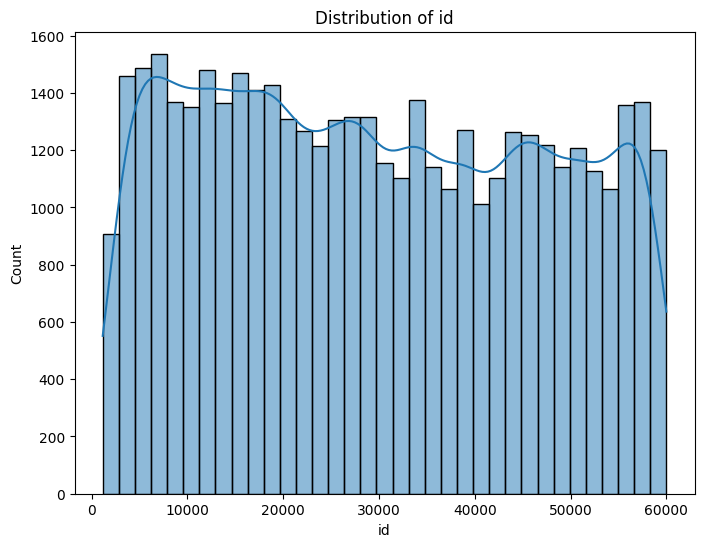

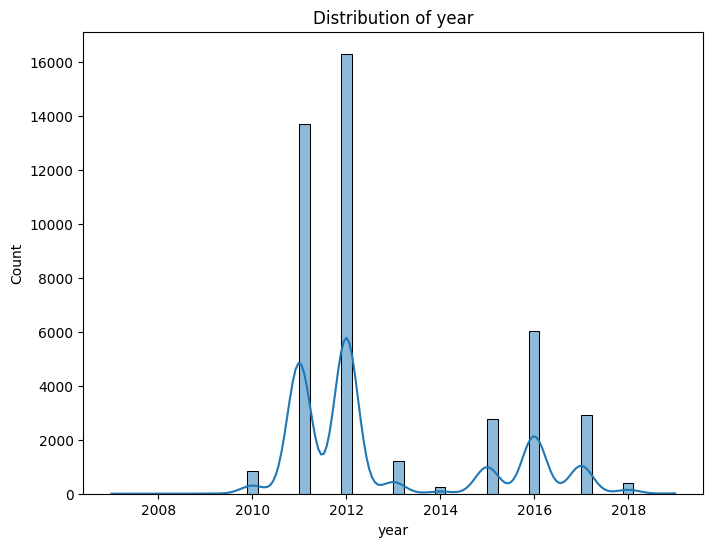

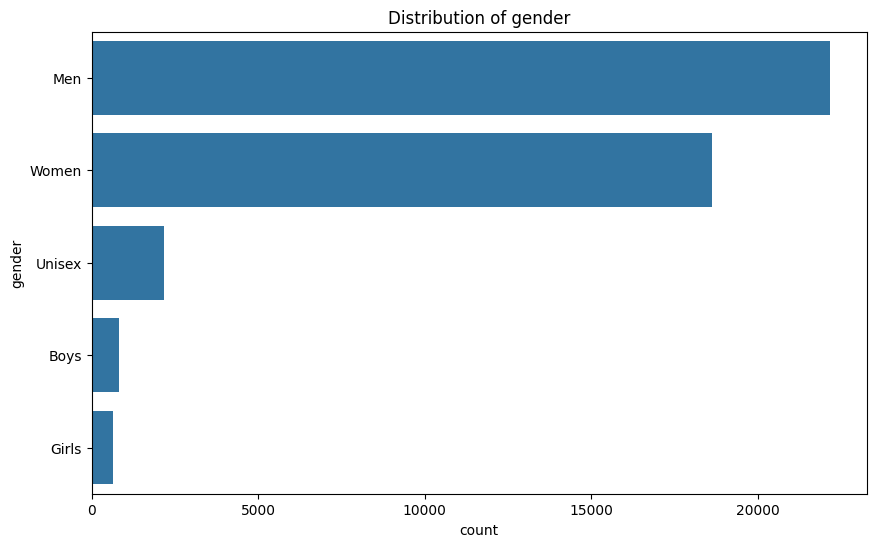

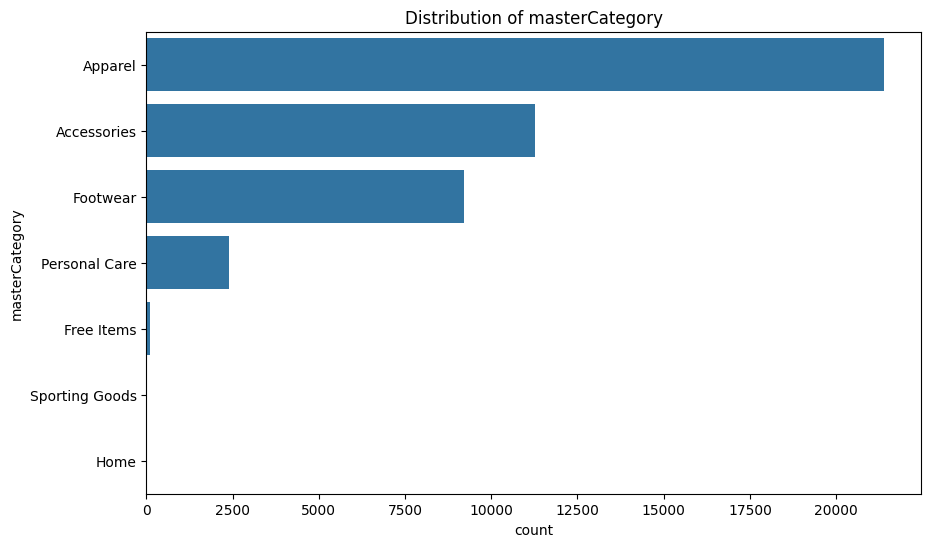

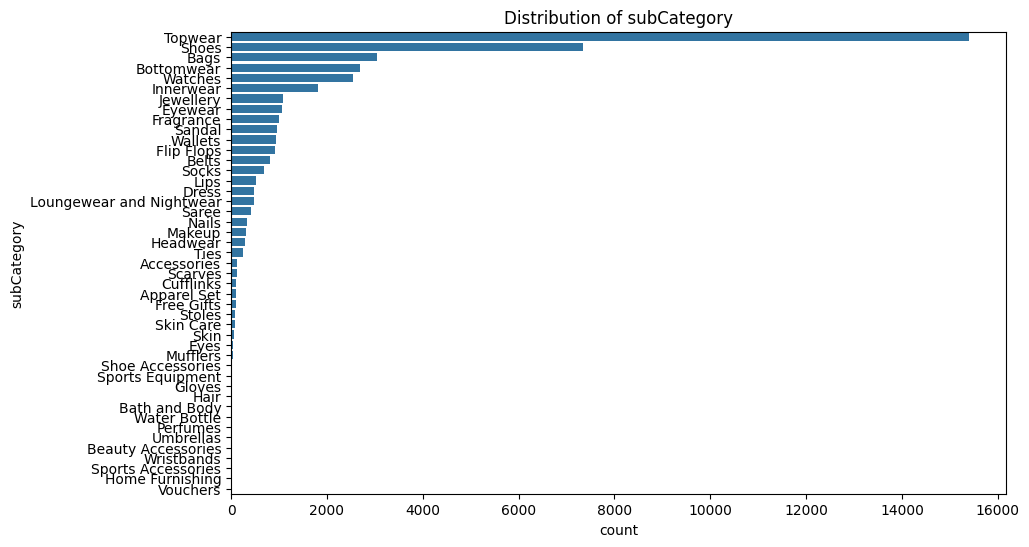

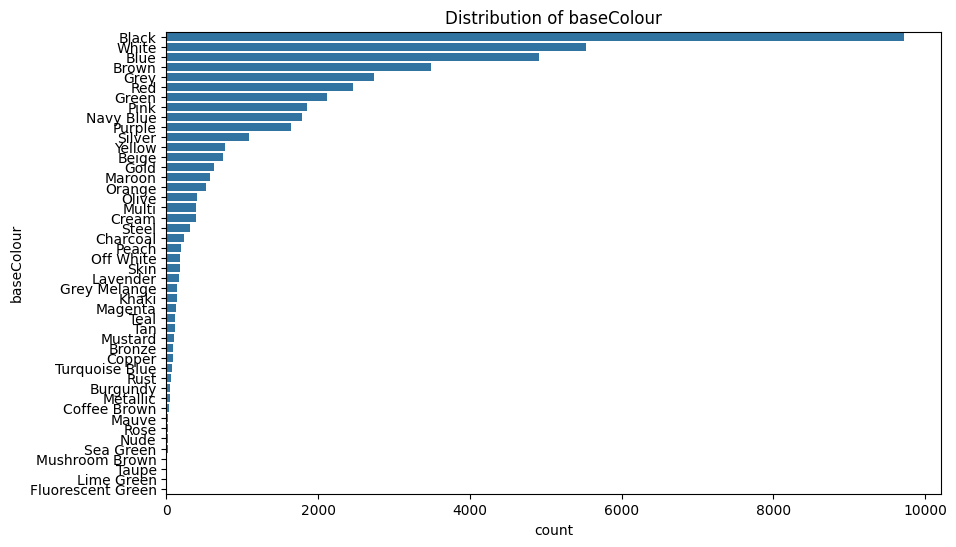

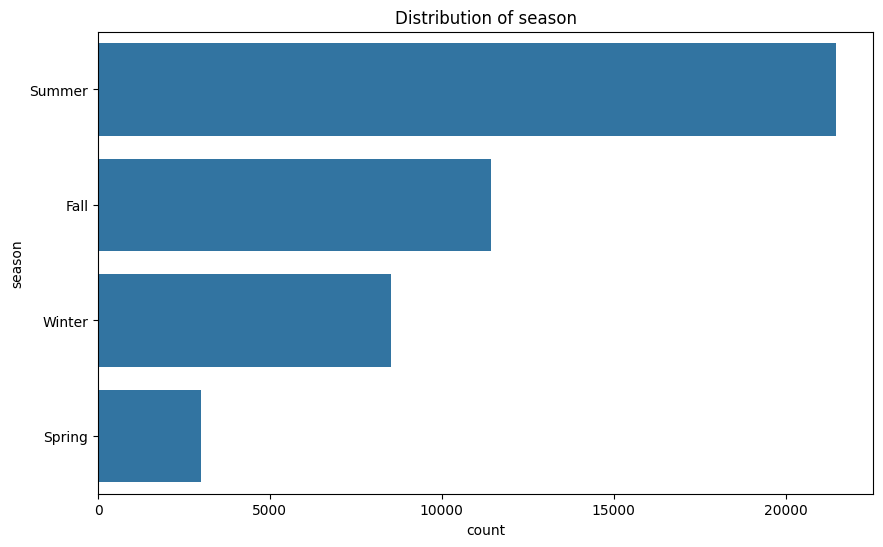

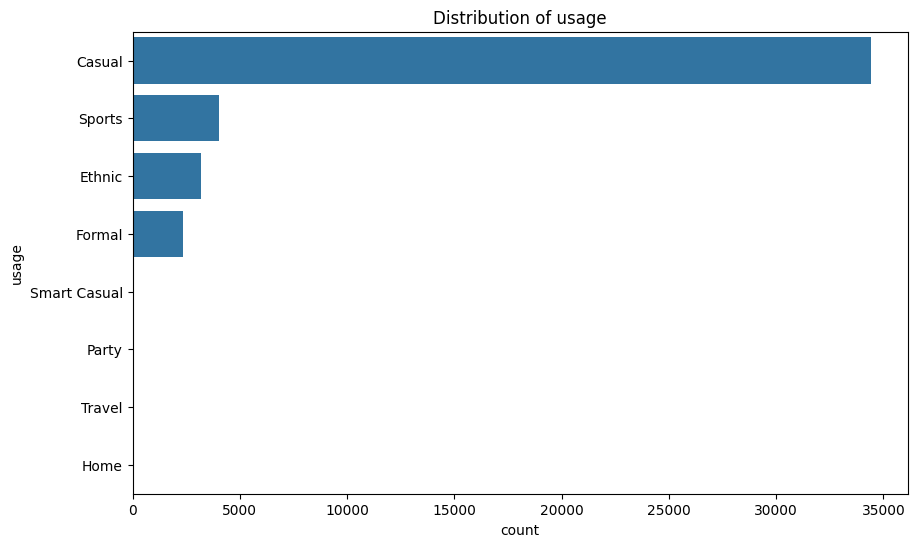


--- Noise Assessment (Manual Inspection Recommended) ---
For text and categorical columns, inspect unique values for typos or inconsistencies.
For numerical columns, histograms can help identify potential outliers.


In [46]:
import pandas as pd
print("\n--- Dataframe Info ---")
df.info()

print("\n--- Missing Value Percentages ---")
for col in df.columns:
    missing_percentage = (df[col].isnull().sum() / len(df)) * 100
    print(f"{col}: {missing_percentage:.2f}%")

print("\n--- Unique Value Counts (Categorical Columns) ---")
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(f"  Number of unique values: {df[col].nunique()}")
    print(f"  First 5 unique values: {df[col].unique()[:5]}")

print("\n--- Descriptive Statistics (Numerical Columns) ---")
print(df.describe())

# --- Task-Specific Usefulness (Initial Thoughts) ---
print("\n--- Potential Usefulness for Master Category Classification ---")
print("gender: Categorical, low missing, likely useful.")
print("masterCategory: Categorical, no missing, TARGET VARIABLE.")
print("subCategory: Categorical, no missing, potentially useful (more granular).")
print("articleType: Categorical, no missing, potentially useful (most granular).")
print("baseColour: Categorical, low missing, potentially useful.")
print("season: Categorical, low missing, potentially useful.")
print("year: Numerical, low missing, might have temporal patterns.")
print("usage: Categorical, some missing, potentially useful.")
print("productDisplayName: Text, low missing, could be useful with NLP (out of scope for basic CNN).")
print("id: Numerical, no missing, unique identifier (not a feature).")

# --- Further Exploration (Distribution, Noise) ---
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() < 50:  # Avoid plotting too many categories
        plt.figure(figsize=(10, 6))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Distribution of {col}")
        plt.show()

print("\n--- Noise Assessment (Manual Inspection Recommended) ---")
print("For text and categorical columns, inspect unique values for typos or inconsistencies.")
print("For numerical columns, histograms can help identify potential outliers.")

In [47]:
import pandas as pd
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

print("\n--- Z-score based outlier detection ---")

outlier_threshold = 3

for col in numerical_cols:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers = df[z_scores > outlier_threshold][col]

    if not outliers.empty:
        print(f"\nPotential outliers in column '{col}' (Z-score > {outlier_threshold}):")
        print(outliers.head())
        print(f"Number of potential outliers: {len(outliers)}")
    else:
        print(f"\nNo significant outliers found in column '{col}' (Z-score > {outlier_threshold}).")


--- Z-score based outlier detection ---

No significant outliers found in column 'id' (Z-score > 3).

No significant outliers found in column 'year' (Z-score > 3).


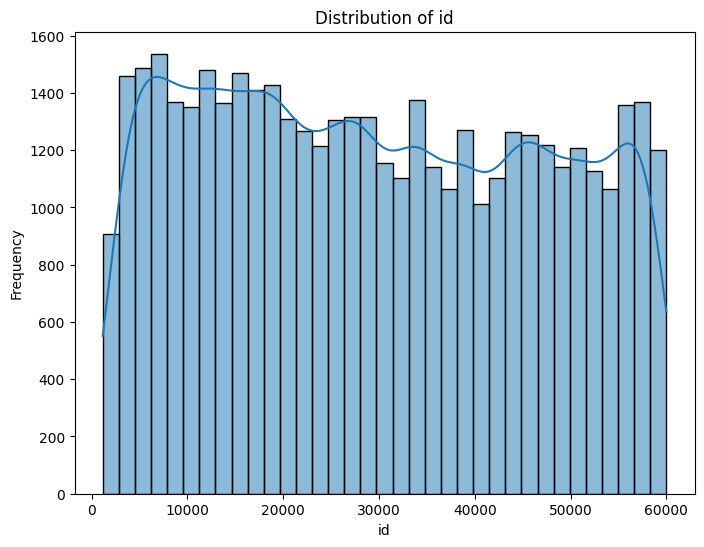

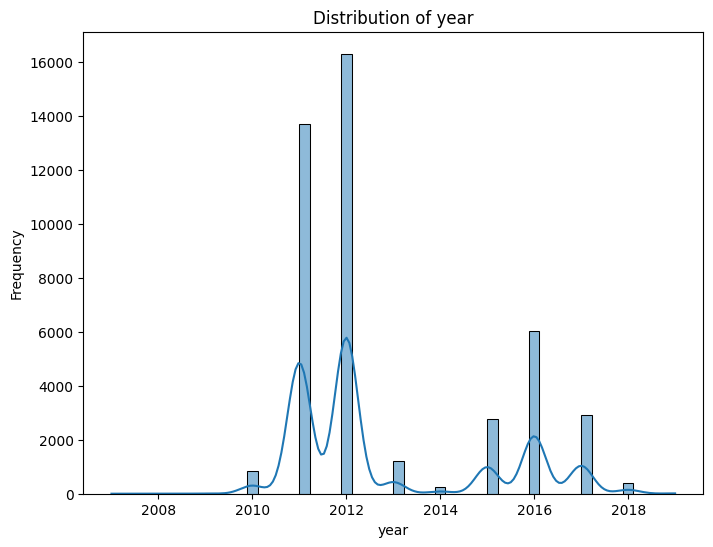

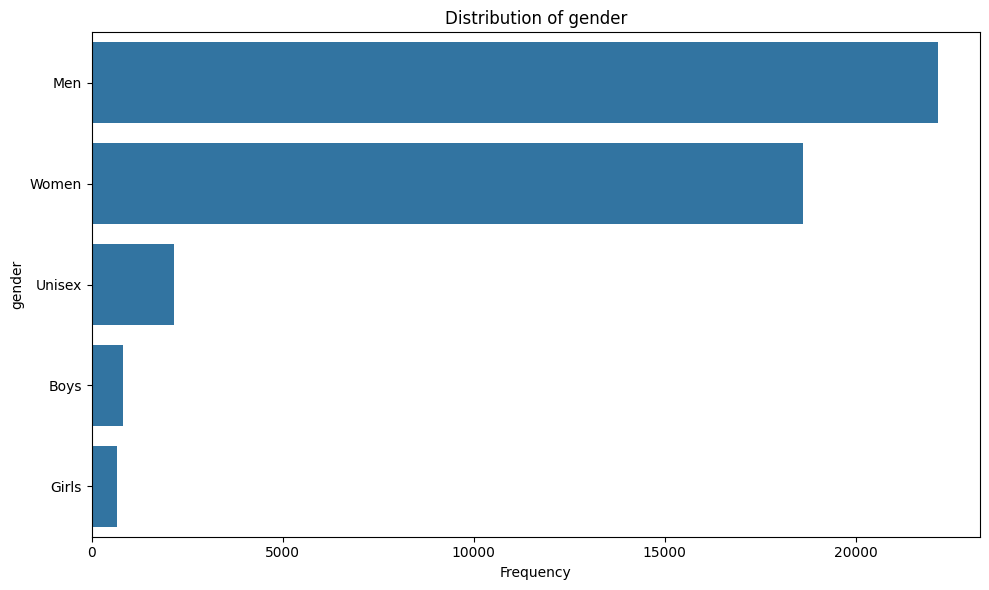

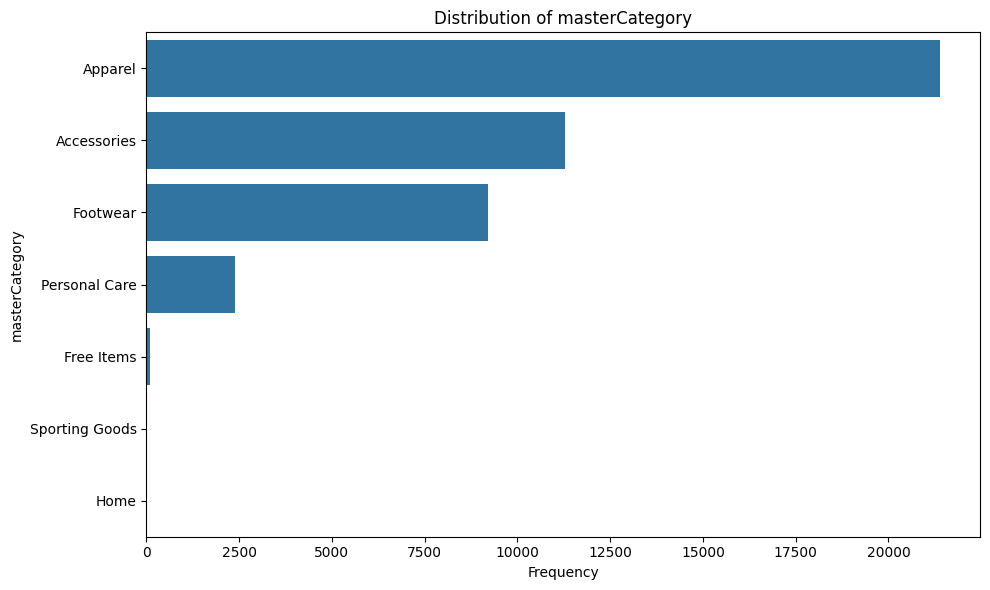

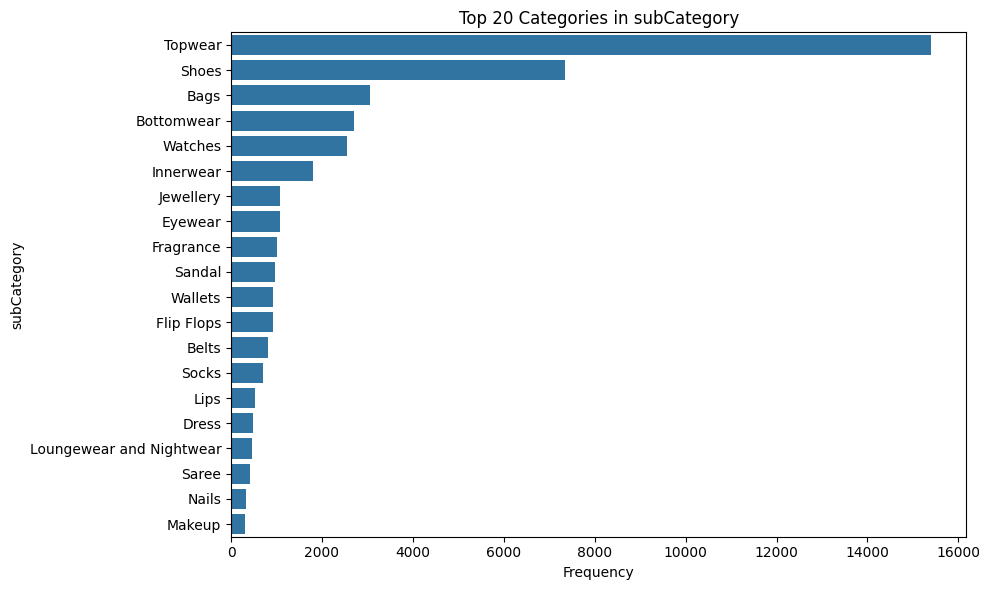

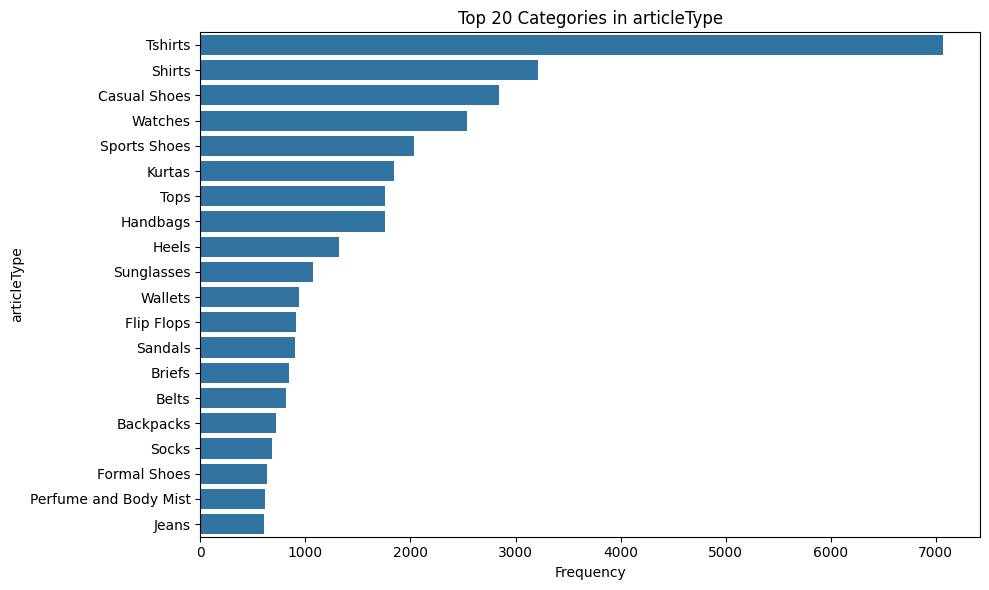

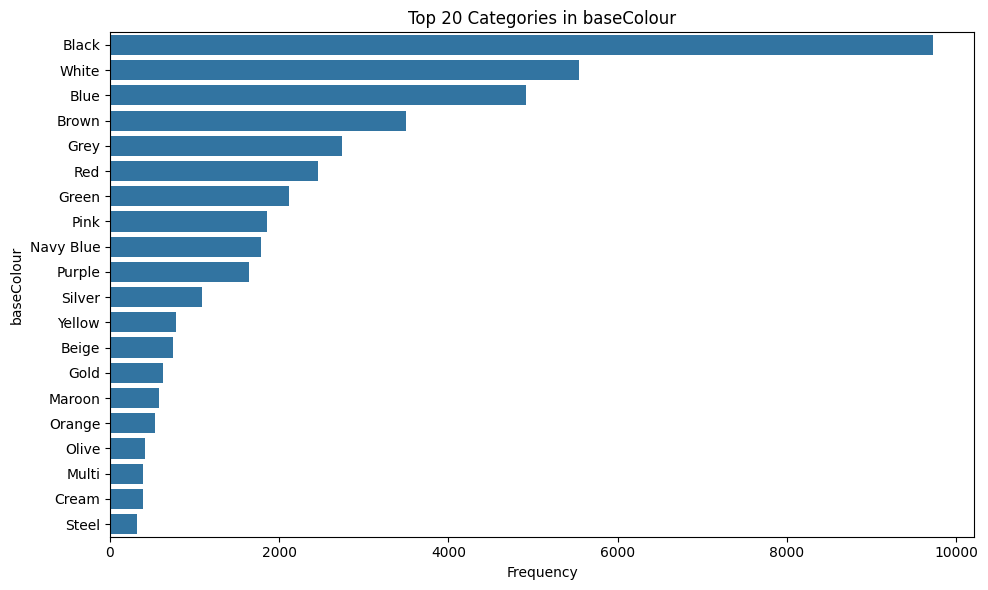

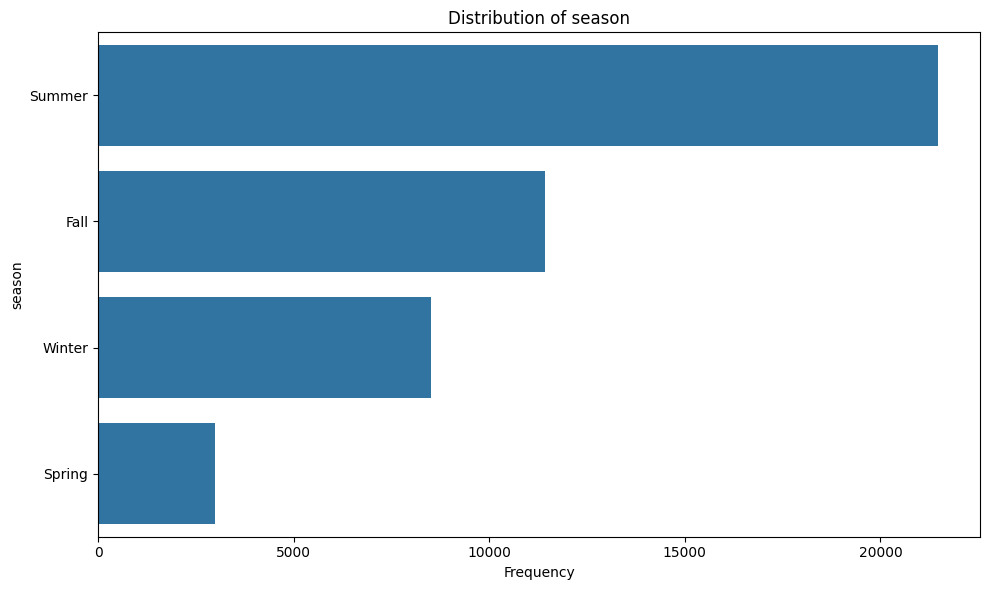

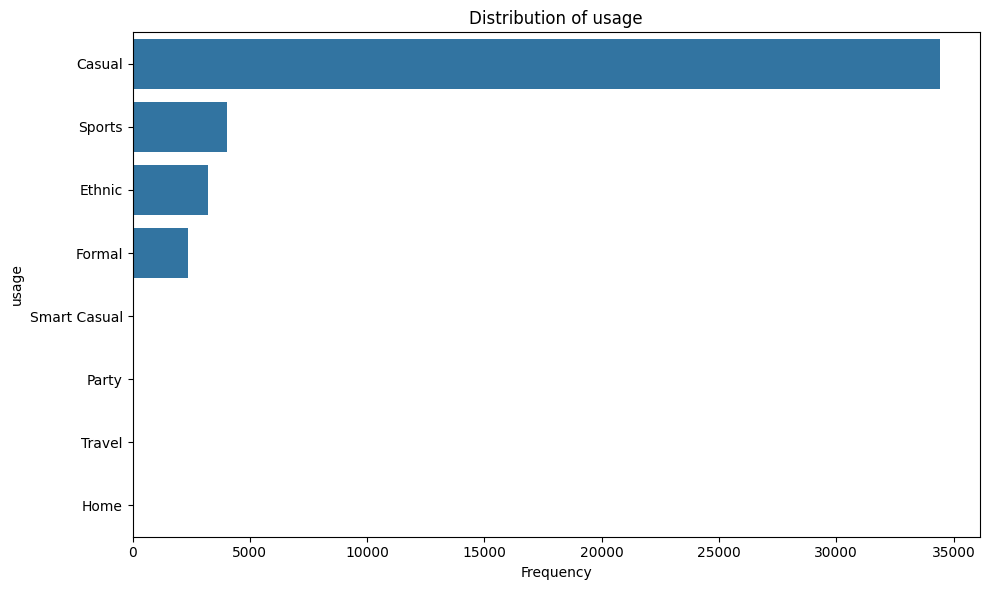

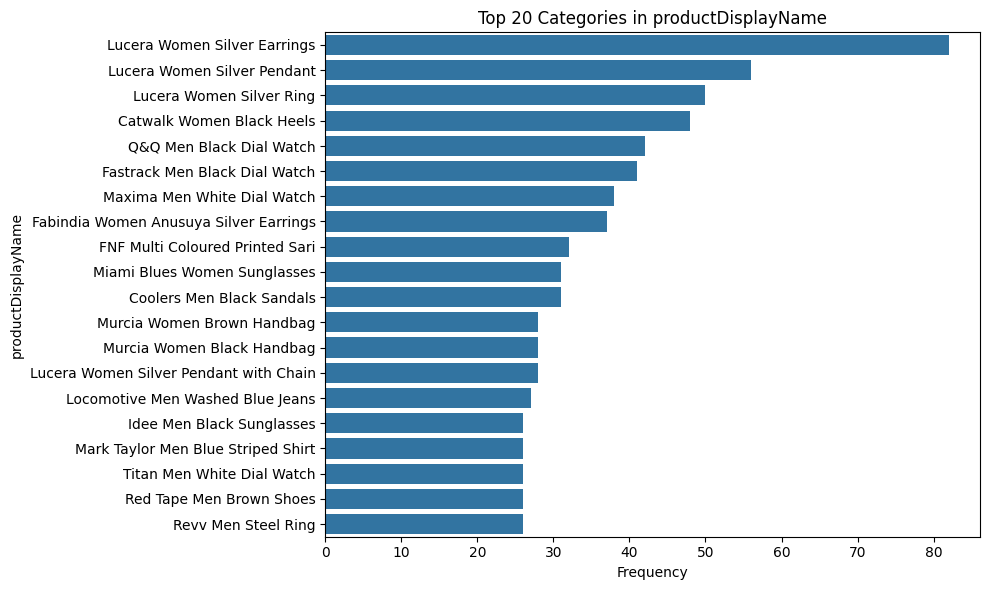

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Distribution of Numerical Features ---
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# --- Distribution of Categorical Features ---
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    if df[col].nunique() > 20:
        # For high cardinality features, show the top 20
        top_n = df[col].value_counts().nlargest(20)
        sns.barplot(x=top_n.values, y=top_n.index)
        plt.title(f'Top 20 Categories in {col}')
        plt.xlabel('Frequency')
        plt.ylabel(col)
    else:
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Frequency')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Conclusions:
Noise: No significant outliers,
Distribution: Uniform
Missing values: None


--- Pearson Correlation Matrix (Numerical Features) ---
            id      year
id    1.000000  0.415051
year  0.415051  1.000000


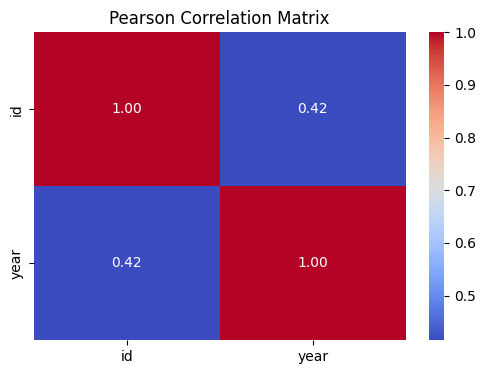

In [49]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_cols.corr(method='pearson')

print("\n--- Pearson Correlation Matrix (Numerical Features) ---")
print(correlation_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

# **Training**

In [50]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- 1. Define Image Size and Batch Size ---
img_height, img_width = 224, 224  # Standard size for many pre-trained models
batch_size = 32

# --- 2. Load Pre-trained ResNet50 (without top layer) ---
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# --- 3. Add Custom Classification Layers ---
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)  # Add a dense layer
num_classes = len(train_df_processed['label'].unique())  # Number of master categories
predictions = Dense(num_classes, activation='softmax')(x)

# --- 4. Create the final model ---
model = Model(inputs=base_model.input, outputs=predictions)

# --- 5. Freeze Pre-trained Layers ---
for layer in base_model.layers:
    layer.trainable = False

# --- 6. Encode Labels ---
label_encoder = LabelEncoder()
train_df_processed['label_encoded'] = label_encoder.fit_transform(train_df_processed['label'])
val_df_processed['label_encoded'] = label_encoder.transform(val_df_processed['label'])
test_df_processed['label_encoded'] = label_encoder.transform(test_df_processed['label'])

train_labels_one_hot = to_categorical(train_df_processed['label_encoded'], num_classes=num_classes)
val_labels_one_hot = to_categorical(val_df_processed['label_encoded'], num_classes=num_classes)
test_labels_one_hot = to_categorical(test_df_processed['label_encoded'], num_classes=num_classes)

print("ResNet50 model created with custom classification layers.")
print(model.summary())

ResNet50 model created with custom classification layers.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 36,433,541 (138.98 MB)

 Trainable params: 12,845,829 (49.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- 1. Define Image Size and Batch Size ---
img_height, img_width = 224, 224
batch_size = 32

# --- 2. Data Augmentation for Training Set ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# --- 3. Data Generator for Validation Set (no augmentation) ---
val_datagen = ImageDataGenerator(rescale=1./255)

# --- 4. Create Data Generators from DataFrames (using original labels) ---
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_processed,
    x_col='image_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df_processed,
    x_col='image_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# --- 5. Compile the Model ---
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 6. Define Callbacks for Training ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath='best_resnet50_model.h5', monitor='val_loss', save_best_only=True)

callbacks = [early_stopping, model_checkpoint]

# --- 7. Train the Model ---
epochs = 15

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    callbacks=callbacks
)

print("\nTraining finished!")

KeyboardInterrupt: 